# Transpilation

---
#### Up until now we have been working with circuits on a somewhat abstract level. We have built circuits with whatever combination of gates took our fancy, with however many qubits we wanted, and simply ran them on a simulator.

#### In this notebook we will learn how to convert our abstract representations of circuits into real, executable circuits on "real" hardware. 

#### Let's take a fake hardware backend and inspect some of it's limitations.

In [32]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

fake_backend = FakeManilaV2()
coupling_map = fake_backend.coupling_map

target = fake_backend.target

print("Coupling Map:", coupling_map)
print("Target:", target)

Coupling Map: [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]]
Target: Target
Number of qubits: 5
Instructions:
	if_else
	switch_case
	rz
		(0,):
			Duration: 0 sec.
			Error Rate: 0
		(1,):
			Duration: 0 sec.
			Error Rate: 0
		(2,):
			Duration: 0 sec.
			Error Rate: 0
		(3,):
			Duration: 0 sec.
			Error Rate: 0
		(4,):
			Duration: 0 sec.
			Error Rate: 0
	for_loop
	id
		(0,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000155066
		(1,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000392193
		(2,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000745816
		(3,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000212219
		(4,):
			Duration: 3.55556e-08 sec.
			Error Rate: 0.000353872
	measure
		(0,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0353
		(1,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0219
		(2,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0964
		(3,):
			Duration: 5.35111e-06 sec.
			Error Rate: 0.0144
		(4,):
			Duration: 5.35111e-06 

### So it seems our backend: 
- ### has only 5 qubits,
- ### is not all-to-all connected (ie we cannot apply 2 qubits gates between any arbitrary pair of qubits), 
- ### and has a somewhat limited gate set. 

### How then can we run our circuits?

### For example, what if I want to apply a CNOT between qubit 0 and qubit 3? In the hardware we chose, only nearest neighbour qubits are connected to each other (meaning two qubit gates are exclusivley provided between neighbouring pairs of qubits.)

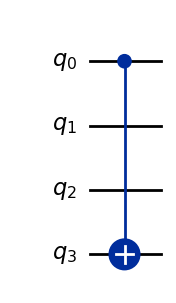

In [33]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(4)
qc.cx(0, 3)

qc.draw(output='mpl')

### One way of accomplishing this could be to use SWAP gates (a two qubit gate which literally swaps the state of qubit A with qubit B.)

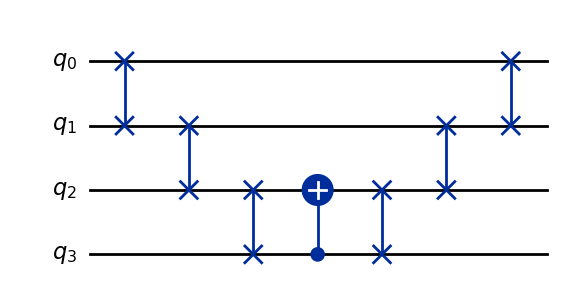

In [34]:
qc_4 = QuantumCircuit(4)

# Move qubit 0 next to qubit 3 using SWAPs
qc_4.swap(0, 1)
qc_4.swap(1, 2)
qc_4.swap(2, 3)


# Now qubit 0 is effectively at position 3
# Apply CX (now local, but at huge cost)
qc_4.cx(3,2)  # control = original qubit 0, target = original qubit 3

# Swap everything back
qc_4.swap(2, 3)
qc_4.swap(1, 2)
qc_4.swap(0, 1)

qc_4.draw("mpl")

### And if our hardware backend doesn't support SWAP gates?

### It turns out the SWAP gate is equivalent to applying CNOT gates alternating the target and control qubit

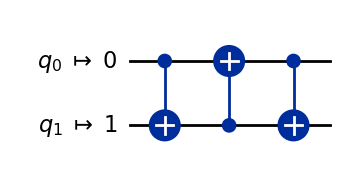

In [36]:
from qiskit import transpile

qc = QuantumCircuit(2)
qc.swap(0, 1)
qc_transpiled = transpile(qc, target=target, optimization_level=0)

qc_transpiled.draw(output='mpl')   

### This is an example of a transpilation. We went from an abstract representation of an operation we wanted to apply (a swap gate), and converted it into operations that our hardware supports. 

### So if we want to apply CNOT between qubit 0 and qubit 3, we can first swap qubit 0 down to qubit 3, apply CNOT between 3 and 2, and then swap all the qubits back.

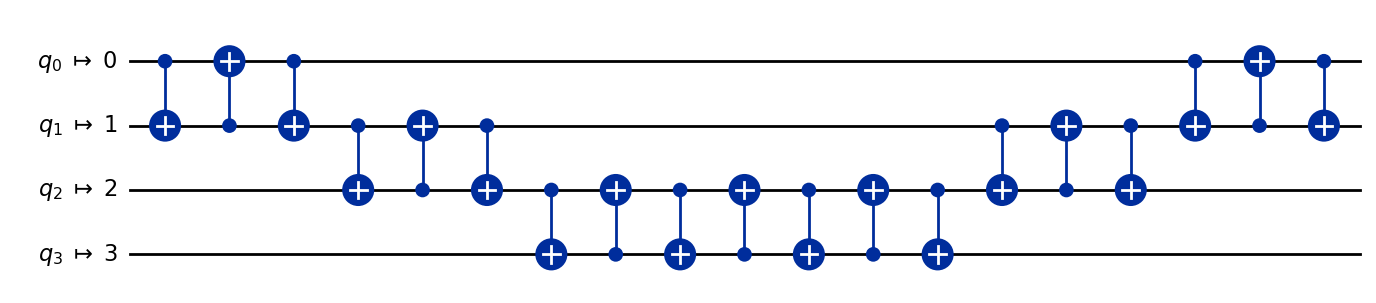

In [89]:
qc_4_transpiled = transpile(circuits=qc_4, backend=fake_backend, optimization_level=1)

qc_4_transpiled.draw("mpl")

### However, as you might guess doing all these two qubit gates can become expensive. 

In [38]:
cx_time = fake_backend.properties().gate_length(gate="cx", qubits=[0,1])
x_time = fake_backend.properties().gate_length(gate="x", qubits=[0])

print(f" 2 qubit gate time = {cx_time*10**6} microseconds")
print(f" 1 qubit gate time = {x_time*10**6} microseconds")

print(f"CX gate cost relative to one X gate = {(qc_4_transpiled.depth() * cx_time) / x_time}")

 2 qubit gate time = 0.2773333333333333 microseconds
 1 qubit gate time = 0.035555555555555556 microseconds
CX gate cost relative to one X gate = 148.2


### Fortunately, we can make our transpiler be a bit smarter by changing the optimzation level.

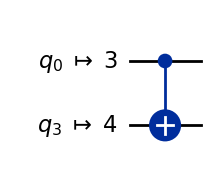

In [42]:
qc_4_transpiled = transpile(circuits=qc_4, backend=fake_backend, optimization_level=3)

qc_4_transpiled.draw("mpl")

## Transpilation is Hardware Specific

### The way our high level circuit will transpile will differ depending on the architecture and native gate set we choose. For example, Manila is linearly connected, but other chips might have more sophisticated connectivity. 

In [43]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_chip_layout(backend, ax, title="Quantum Chip Layout"):
    """
    Draws the coupling map of a backend onto a specific subplot axis.
    """
    # 1. Get edges from the backend coupling map
    edges = backend.coupling_map.get_edges()
    
    # 2. Build the Graph
    G = nx.Graph()
    G.add_edges_from(edges)
    
    # 3. Choose a layout (Kamada-Kawai looks more 'hardware-like')
    pos = nx.kamada_kawai_layout(G)
    
    # 4. Draw to the specific 'ax' provided
    nx.draw(G, pos, 
            ax=ax,
            with_labels=True, 
            node_color='#61dafb', 
            node_size=600, 
            font_size=10, 
            font_weight='bold',
            edge_color='gray',
            width=1.5)
    
    ax.set_title(title, fontsize=14)

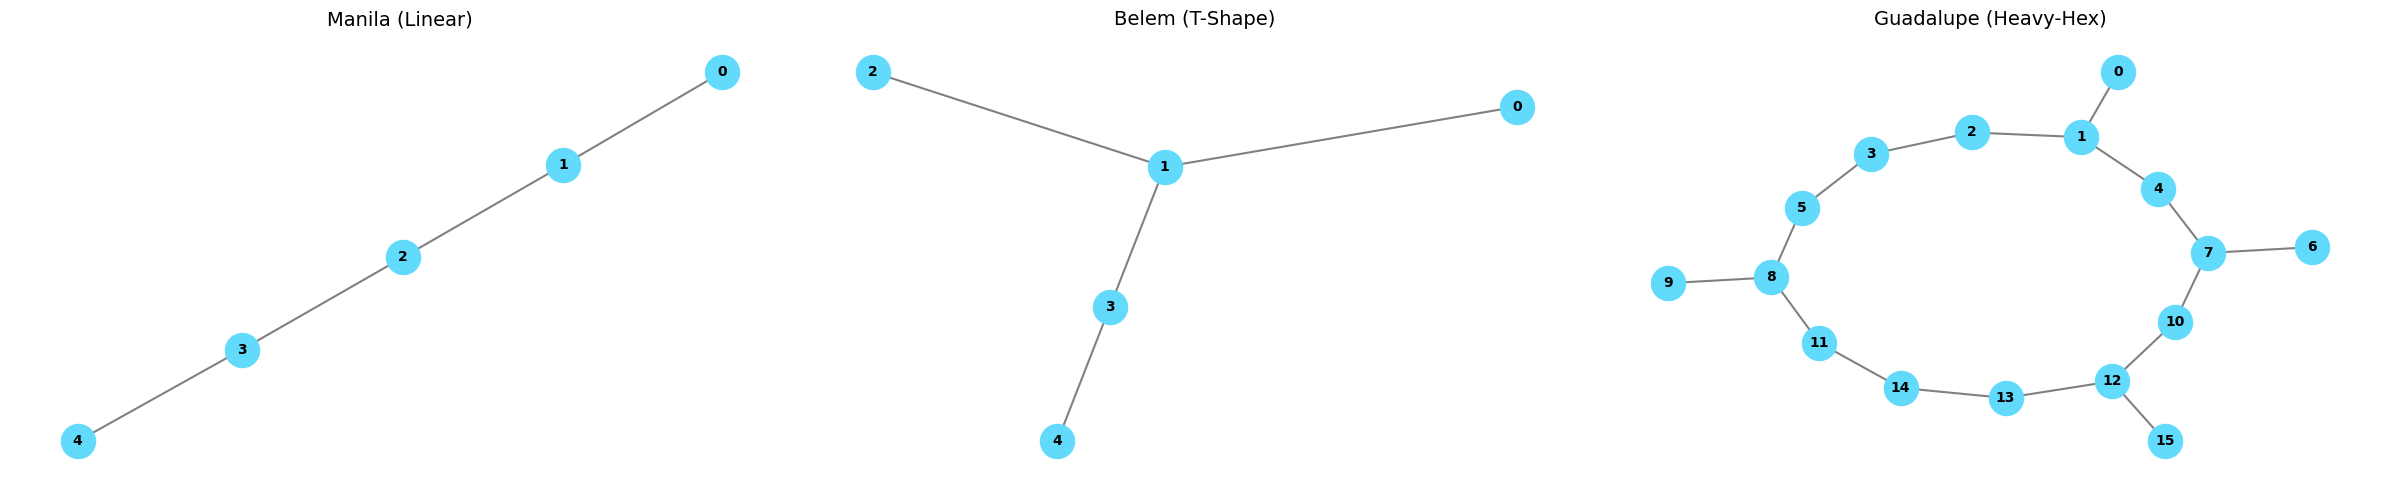

In [44]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2, FakeBelemV2, FakeGuadalupeV2

backend_manila = FakeManilaV2() # Linear connectivity (0-1-2-3-4)
backend_belem = FakeBelemV2()   # T-shape connectivity
backend_guadalupe = FakeGuadalupeV2()

fig, axes = plt.subplots(1, 3, figsize=(24, 5))

draw_chip_layout(FakeManilaV2(), axes[0], "Manila (Linear)")
draw_chip_layout(FakeBelemV2(), axes[1], "Belem (T-Shape)")
draw_chip_layout(FakeGuadalupeV2(), axes[2], "Guadalupe (Heavy-Hex)")

plt.tight_layout()
plt.show()

Successfully authenticated! Connected to: ibm_marrakesh
[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [3, 16], [4, 3], [4, 5], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [7, 17], [8, 7], [8, 9], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [11, 18], [12, 11], [12, 13], [13, 12], [13, 14], [14, 13], [14, 15], [15, 14], [15, 19], [16, 3], [16, 23], [17, 7], [17, 27], [18, 11], [18, 31], [19, 15], [19, 35], [20, 21], [21, 20], [21, 22], [21, 36], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 37], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 38], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 34], [33, 39], [34, 33], [34, 35], [35, 19], [35, 34], [36, 21], [36, 41], [37, 25], [37, 45], [38, 29], [38, 49], [39, 33], [39, 53], [40, 41], [41, 36], [41, 40], [41, 42], [42, 41], [42, 43], [43, 42], [43, 44], [43, 56], [44, 43], [44, 

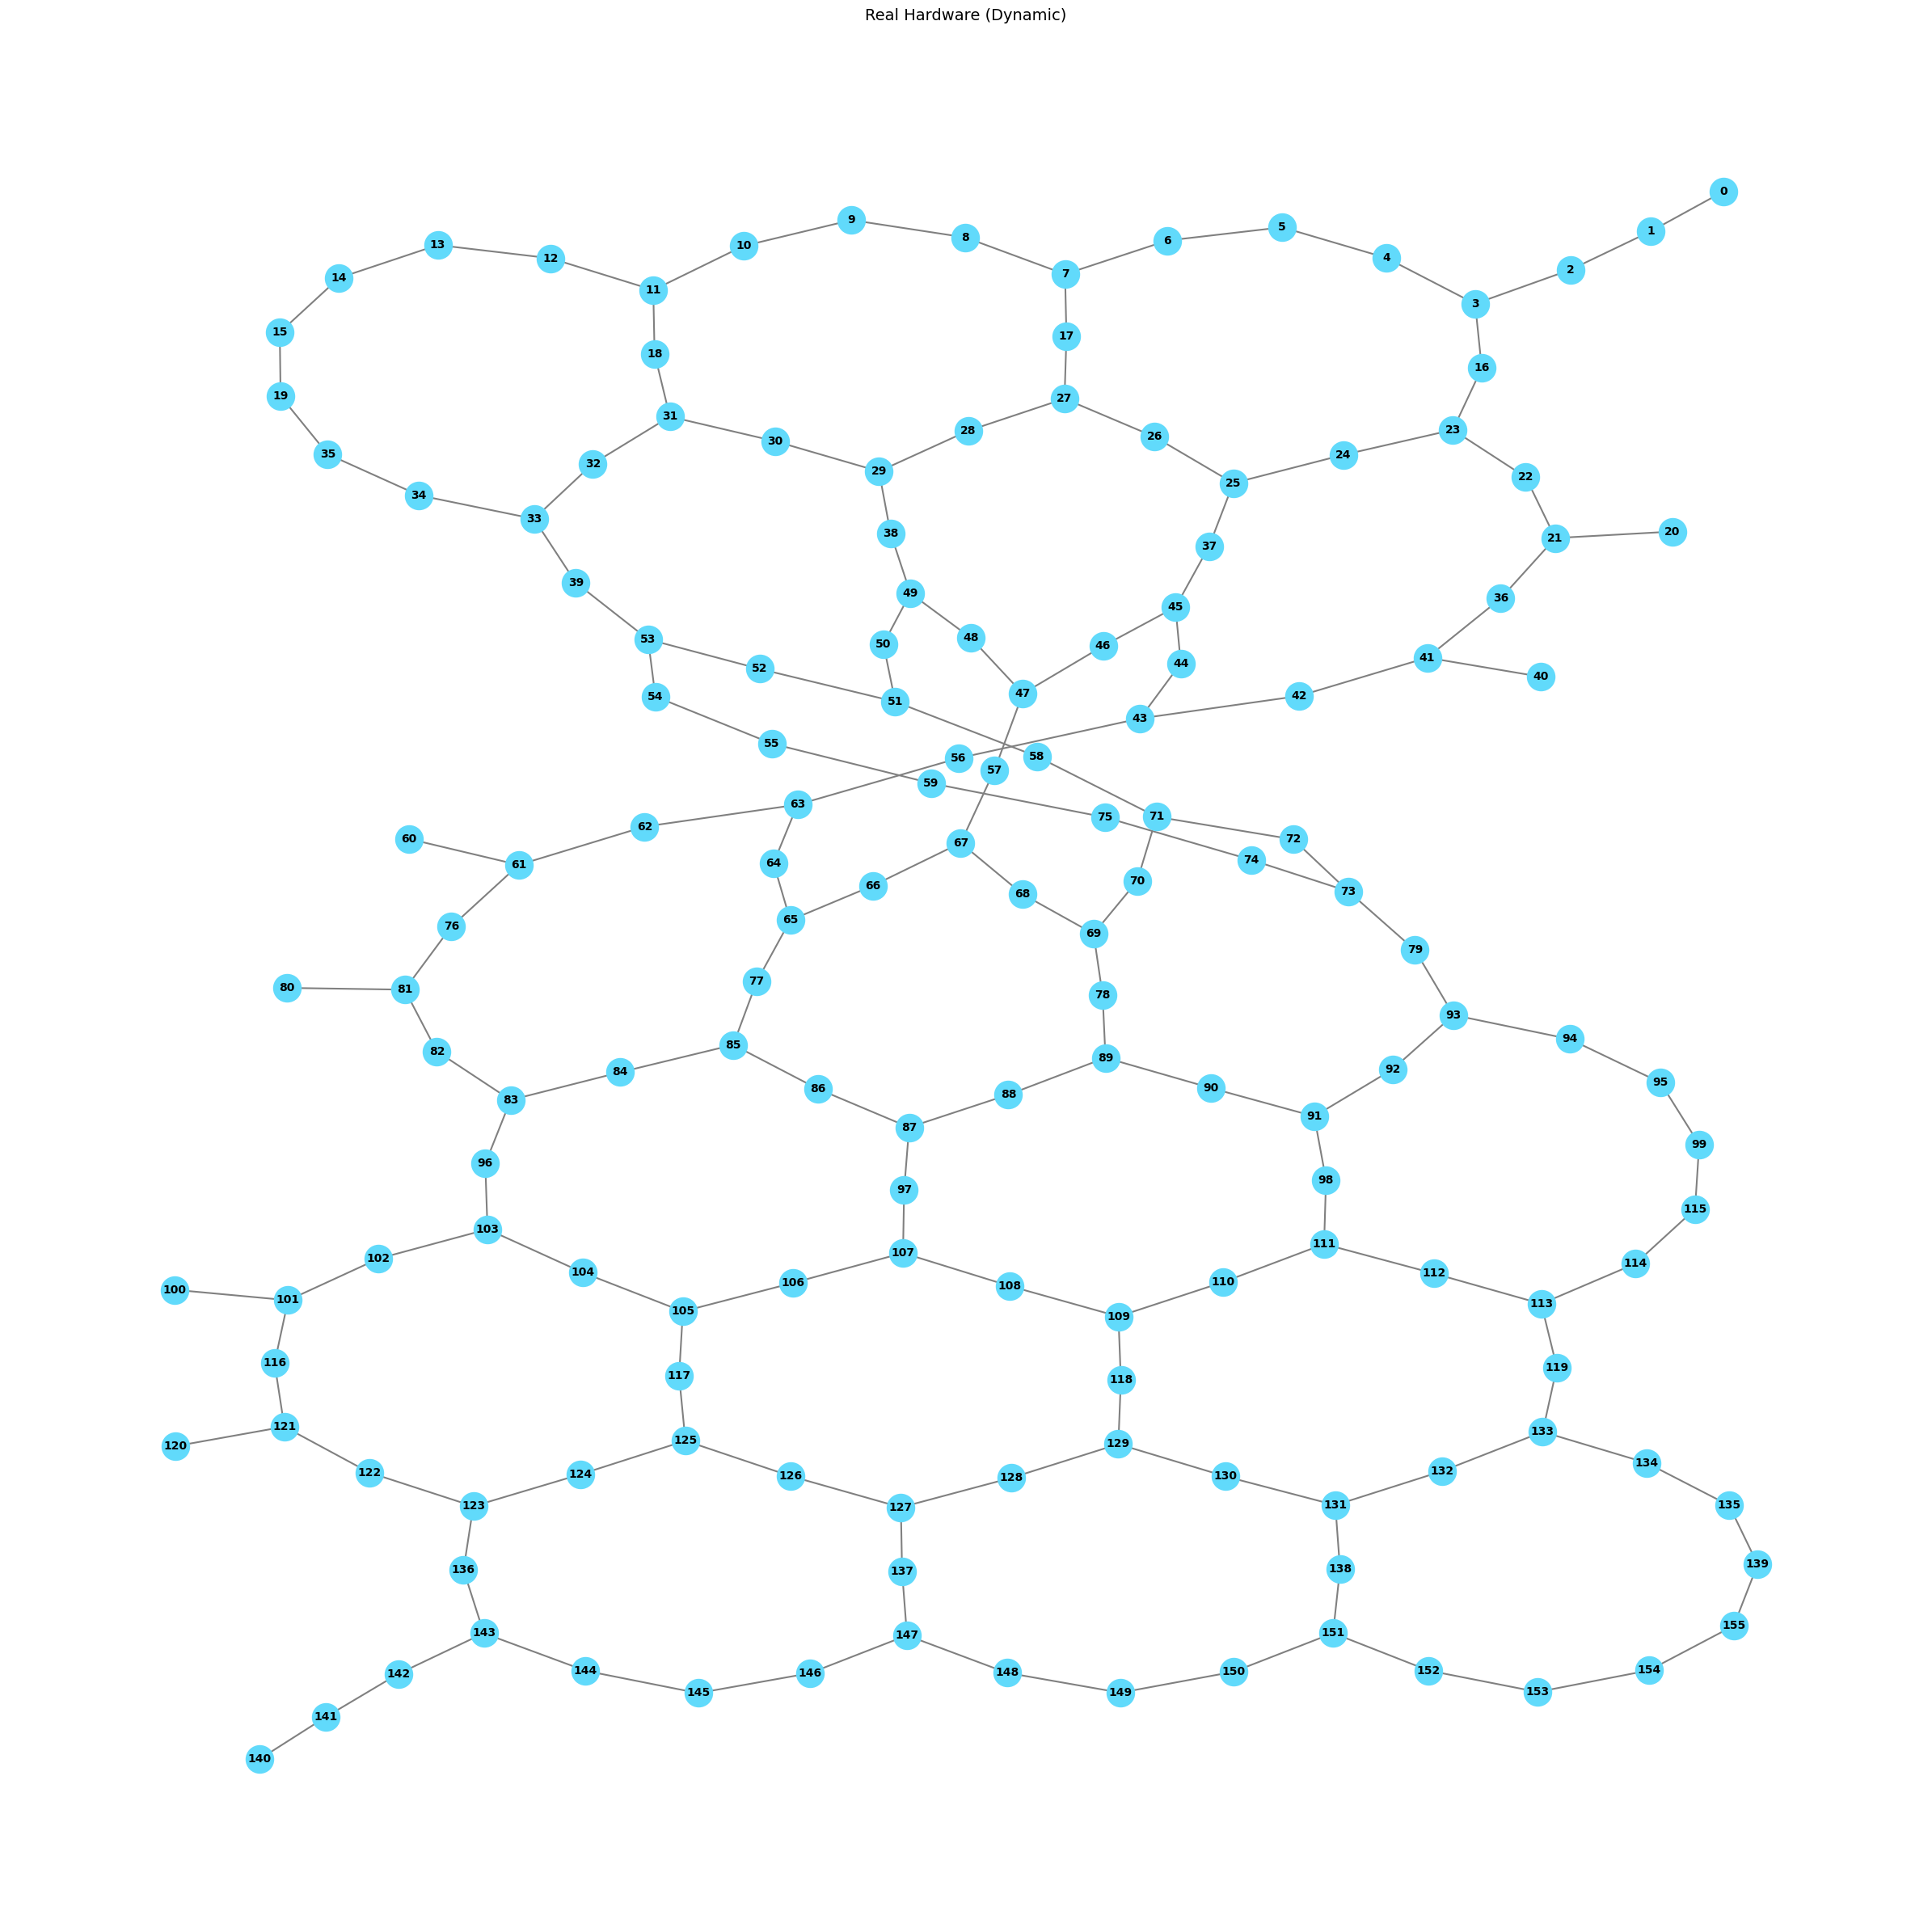

In [45]:
from qiskit_ibm_runtime import QiskitRuntimeService
import os

# QiskitRuntimeService.save_account(
#     token = os.getenv("QISKIT_API_KEY"),
#     instance = os.getenv("INSTANCE")
# )

service = QiskitRuntimeService()
real_backend = service.least_busy(simulator=False, operational=True)
print(f"Successfully authenticated! Connected to: {real_backend.name}")
print(real_backend.coupling_map)

fig, axes = plt.subplots(1, 1, figsize=(24, 24))
draw_chip_layout(real_backend, axes, "Real Hardware (Dynamic)")

plt.tight_layout()
plt.show()

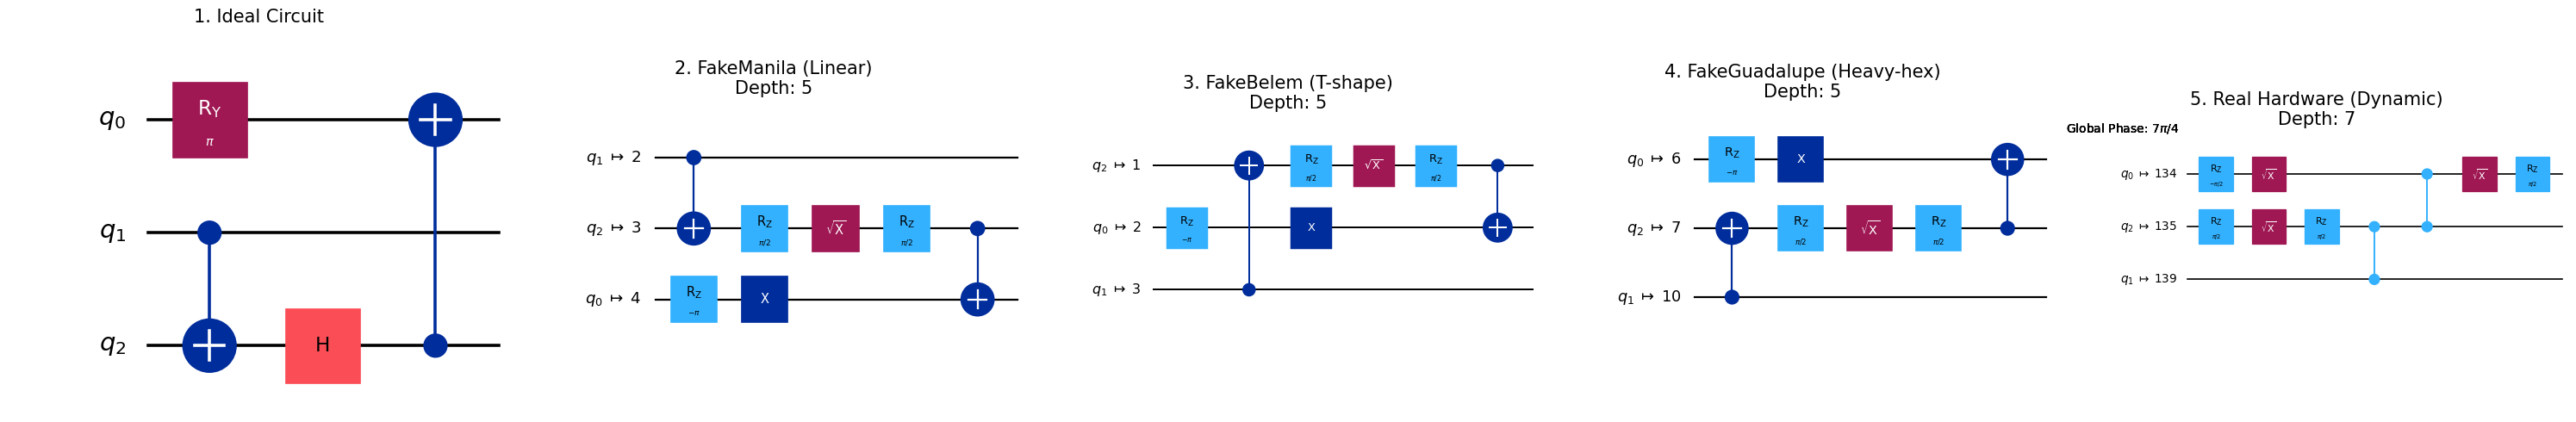

In [47]:
import numpy as np

qc_3 = QuantumCircuit(3)
qc_3.ry(theta=np.pi, qubit=0)
qc_3.cx(1,2)
qc_3.h(2)
qc_3.cx(2,0)

opt_level = 3

qc_manila = transpile(qc_3, backend=backend_manila, optimization_level=opt_level)
qc_belem = transpile(qc_3, backend=backend_belem, optimization_level=opt_level)
qc_guadalupe = transpile(qc_3, backend=backend_guadalupe, optimization_level=opt_level)
qc_real = transpile(qc_3, backend=real_backend, optimization_level=opt_level)

fig, ax = plt.subplots(1, 5, figsize=(30, 7))

# Original
qc_3.draw('mpl', ax=ax[0])
ax[0].set_title("1. Ideal Circuit", fontsize=15)

# Manila Version
qc_manila.draw('mpl', ax=ax[1])
ax[1].set_title(f"2. FakeManila (Linear)\nDepth: {qc_manila.depth()}", fontsize=15)

# Belem Version
qc_belem.draw('mpl', ax=ax[2])
ax[2].set_title(f"3. FakeBelem (T-shape)\nDepth: {qc_belem.depth()}", fontsize=15)

# Guadalope Version
qc_guadalupe.draw('mpl', ax=ax[3])
ax[3].set_title(f"4. FakeGuadalupe (Heavy-hex)\nDepth: {qc_guadalupe.depth()}", fontsize=15)

# Real Hardware Version
qc_real.draw('mpl', ax=ax[4])
ax[4].set_title(f"5. Real Hardware (Dynamic)\nDepth: {qc_real.depth()}", fontsize=15)

plt.tight_layout()
plt.show()

---

# Native gate sets

### As already mentioned, not gate is supported on every hardware. The set of gates that are supported by a hardware backend is called its **Native Gateset**. 

### We have already seen one example of how a hardware backend will handle transpiling a non-native gate in the SWAP gate being equivalent to 3 CNOT gates.

In [48]:
fake_backend = FakeManilaV2()
target = fake_backend.target
print(target.operation_names)

dict_keys(['if_else', 'switch_case', 'rz', 'for_loop', 'id', 'measure', 'reset', 'sx', 'delay', 'x', 'cx'])


## Let's go through some of the missing gates in Manila and see how it handles them in transpilation.

## Y gate

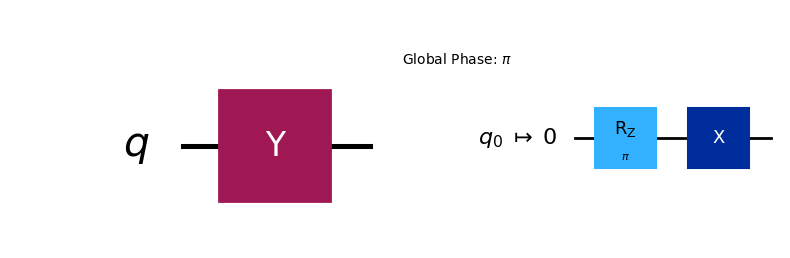

In [50]:
qc_y = QuantumCircuit(1)
qc_y.y(0)
qc_y_transpiled = transpile(circuits=qc_y, target=target, optimization_level=3)
qc_y_transpiled.draw(output='mpl')

fig, ax = plt.subplots(1, 2, figsize=(8, 7))

qc_y.draw('mpl', ax=ax[0])

qc_y_transpiled.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

### So in order to apply a Y gate, our transpiler first does a rotation about the Z axis by an angle of π radians (180°) and then an X gate. 

And what's that global phase thing in the corner?


$$
Y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix},
\quad
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix},
\quad
R_z(\pi) =
\begin{pmatrix}
-i & 0 \\
0 & i
\end{pmatrix}
$$

$$
X R_z(\pi)
=
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\begin{pmatrix}
-i & 0 \\
0 & i
\end{pmatrix}
=
\begin{pmatrix}
0 & i \\
-i & 0
\end{pmatrix}
$$

$$
X R_z(\pi) = -Y = e^{i\pi} Y
$$

We see mathetmatically that these two gates are equivalent to the Y gate (up to a global phase).

In quantum mechanics, we don't care about the global phase (a phase that applies over the entire state) because it doesn't affect observable outcomes. In other words, it makes no different to our measurements. 

---

## H gate

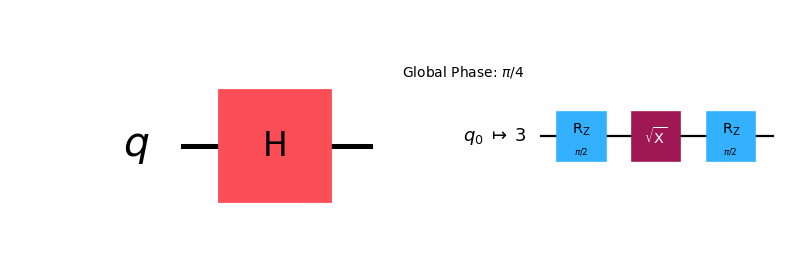

In [17]:
qc_h = QuantumCircuit(1)
qc_h.h(0)
qc_h_transpiled = transpile(circuits=qc_h, target=target)
qc_h_transpiled.draw(output='mpl')

fig, ax = plt.subplots(1, 2, figsize=(8, 7))

qc_h.draw('mpl', ax=ax[0])
qc_h_transpiled.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

---
## Rx and Ry

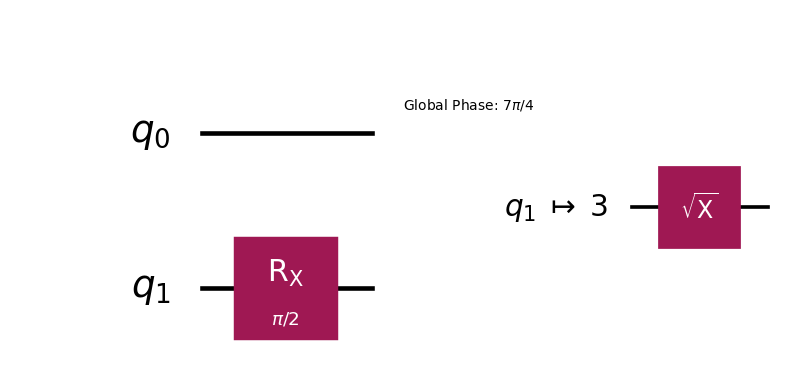

In [84]:
qc_ry = QuantumCircuit(2)
qc_ry.rx(np.pi/2, qubit=1)
qc_ry_transpiled = transpile(circuits=qc_ry, target=target)
qc_ry_transpiled.draw(output='mpl')

fig, ax = plt.subplots(1, 2, figsize=(8, 7))

qc_ry.draw('mpl', ax=ax[0])
qc_ry_transpiled.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

---
## Rzz

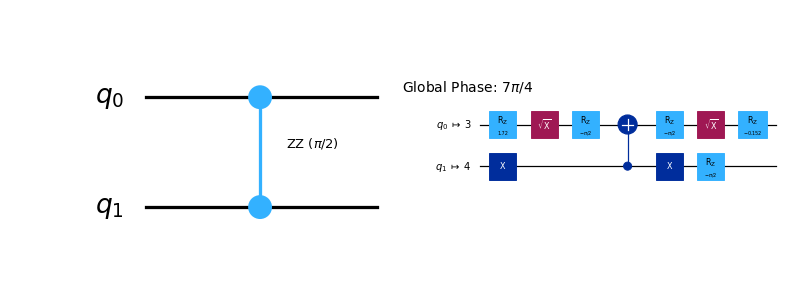

In [62]:
qc_rzz = QuantumCircuit(2)
qc_rzz.rzz(theta=np.pi/2, qubit1=0, qubit2=1)
qc_rzz_transpiled = transpile(circuits=qc_rzz, target=target, optimization_level=2)
qc_rzz_transpiled.draw(output='mpl')

fig, ax = plt.subplots(1, 2, figsize=(8, 7))

qc_rzz.draw('mpl', ax=ax[0])
qc_rzz_transpiled.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

## Exercise: Change the optimization level for the transpilation of Rzz. What changes for this higher level of optimization? Can you make any guesses as to why? Does this hold for all values of theta (rotation angle)?

---

## Rzzz...

Underful Vlist: Vlist<w=4.22 h=4.27 d=0.00 s=0.00>[Hrule, Glue, Hlist<w=4.22 h=4.00 d=0.00 s=0.00>[Hbox, Hlist<w=3.08 h=4.00 d=0.00 s=0.00>[`X`, k0.21], Hbox]]
Underful Vlist: Vlist<w=4.22 h=4.27 d=0.00 s=0.00>[Hrule, Glue, Hlist<w=4.22 h=4.00 d=0.00 s=0.00>[Hbox, Hlist<w=3.08 h=4.00 d=0.00 s=0.00>[`X`, k0.21], Hbox]]


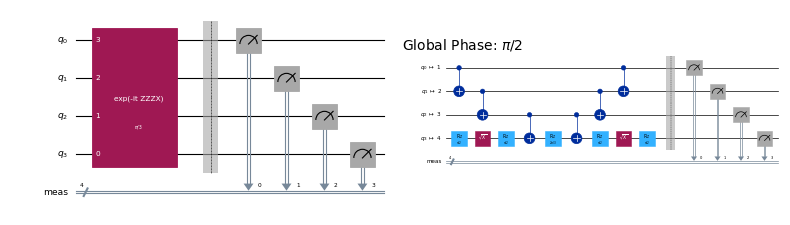

In [69]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Pauli

theta = np.pi/3
pauli_op = Pauli('ZZZX')
qc_rzzz = QuantumCircuit(4)
rzzz = PauliEvolutionGate(pauli_op, time=theta)
qc_rzzz.append(rzzz, [3,2,1,0])


#-------------
qc_rzzz.measure_all()
qc_rzzz_transpiled = transpile(qc_rzzz, target=target, optimization_level=2)

fig, ax = plt.subplots(1, 2, figsize=(8, 7))

qc_rzzz.draw('mpl', ax=ax[0])
qc_rzzz_transpiled.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

### Qiskit’s transpiler automatically converts any circuit into the native gates that a device can run. Gates that aren’t directly supported—like Y, RZZ, or multi-qubit rotations—are broken down into combinations of universal gates such as Rz and CX. 

### Because these gates form a universal gate set, we can build any circuit we want, and the transpiler takes care of mapping it to the hardware so it runs correctly.

---

### Exercise: transpilation is a very nice feature of Qiskit but it can quickly proliferate. Implement some combinations of gates to see how many real gates are typically needed. Hint: multiple qubit gates make a mess.

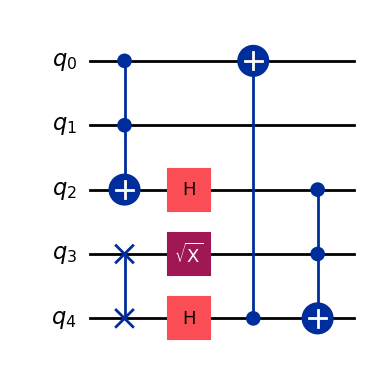

In [92]:
qc_5 = QuantumCircuit(5)

# Mess around here - I'll get you started:
qc_5.ccx(0,1,2)

qc_5.swap(3,4)
qc_5.h(4)
qc_5.sx(3)
qc_5.cx(4,0)
qc_5.h(2)
qc_5.ccx(2,3,4)


qc_5.draw('mpl')

OrderedDict({'rz': 28, 'cx': 23, 'sx': 13})


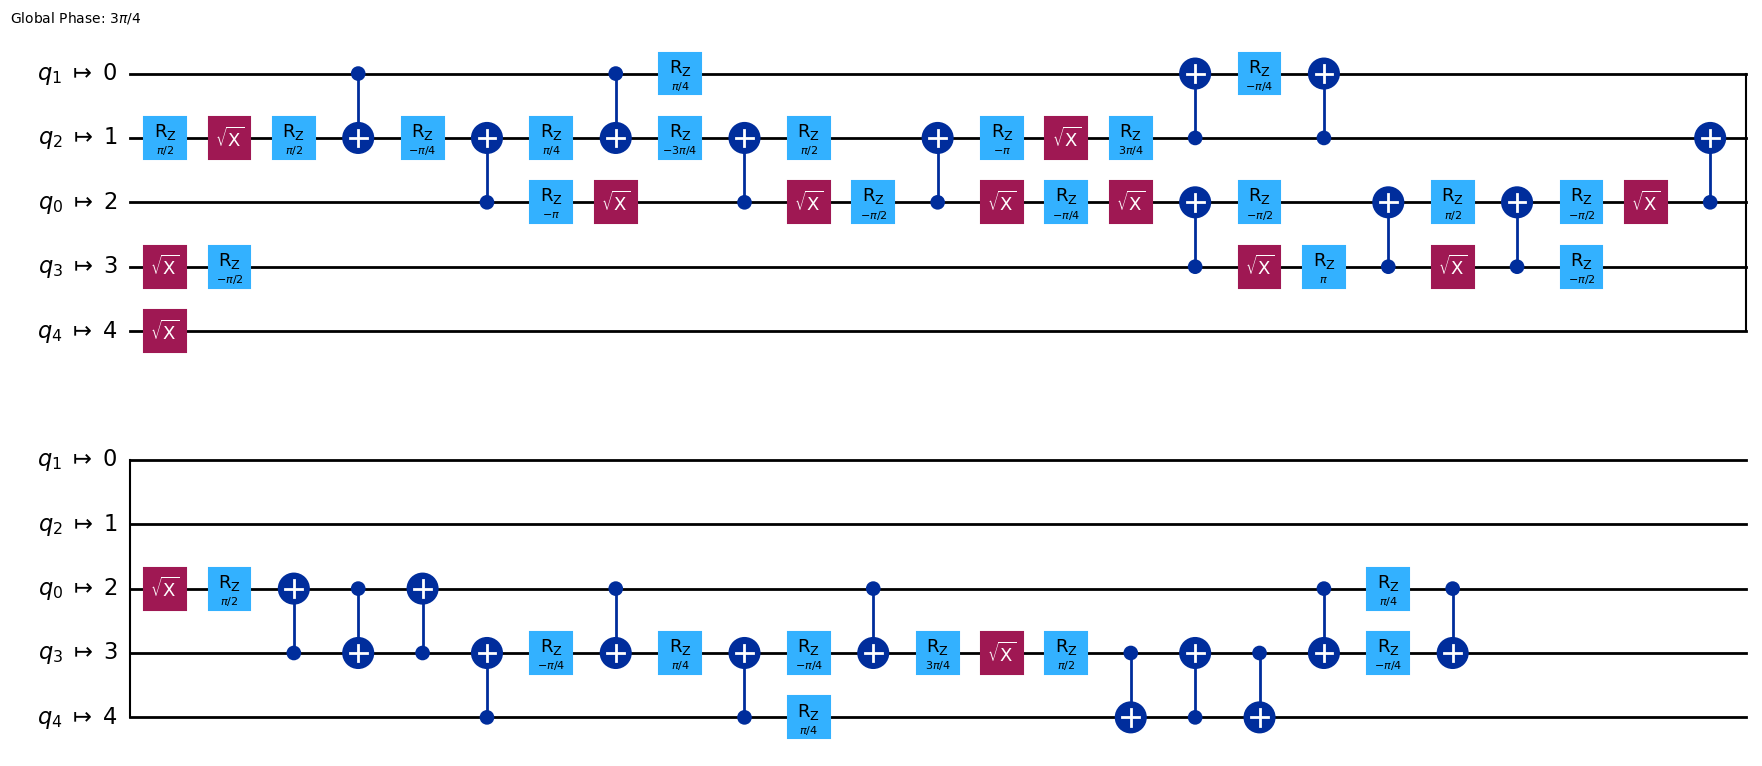

In [96]:
### Transpile here ###

qc_5_transpiled = transpile(qc_5, target=target, optimization_level=3)
print(qc_5_transpiled.count_ops())
qc_5_transpiled.draw("mpl")

Connected to: ibm_marrakesh
{'100': 3, '001': 7}


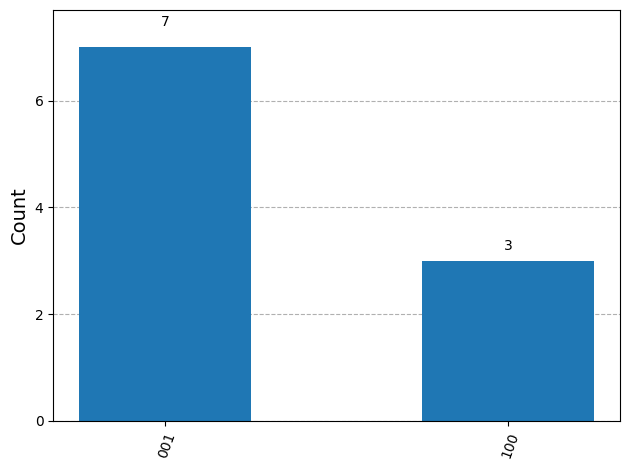

In [97]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# 1. Initialize the Runtime Service (using your saved credentials)
service = QiskitRuntimeService()

# 2. Recreate your circuit & ADD MEASUREMENTS
real_circuit = QuantumCircuit(3)
real_circuit.ry(theta=np.pi, qubit=0)
real_circuit.cx(1, 2)
real_circuit.h(2)
real_circuit.cx(2, 0)
real_circuit.measure_all()  # Crucial for SamplerV2

# 3. Instantiate hardware backend
real_backend = service.least_busy(simulator=False, operational=True)
print(f"Connected to: {real_backend.name}")

# 4. Transpile using the new Pass Manager framework (ISA Circuit compliance)
opt_level = 1
pm = generate_preset_pass_manager(backend=real_backend, optimization_level=opt_level)
isa_circuit = pm.run(real_circuit)

# 5. Initialize the V2 Sampler mapped to your backend
sampler = Sampler(mode=real_backend)

# 6. Run the circuit using Primitive Unified Blocs (PUBs)
# We supply a list containing a tuple: (circuit, parameters_if_any, shots)
job = sampler.run([(isa_circuit, None, 10)]) 
result = job.result()

# 7. Extract the counts from the default "meas" register data structure
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

print(counts)
plot_histogram(counts)

# Appendix

---

---
# Pass Managers

### Up until now, we have used the `transpile()` function. It’s incredibly powerful because it acts like auto-pilot. It looks at your circuit and your backend, then automatically picks a sequence of optimization "passes" it thinks are best.

### However, as a Quantum Engineer, you often need more precision. This is where the `PassManager` comes in.

### We can define a set of `passes` we want our circuit to run through that will optimize in a specific way.

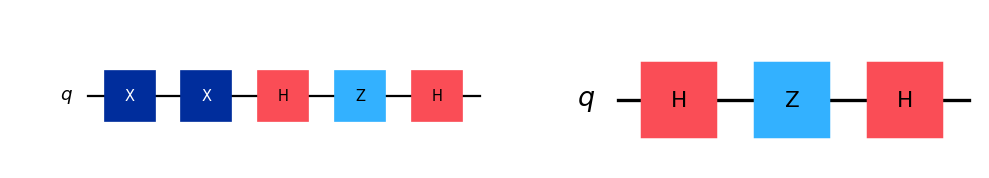

In [46]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import InverseCancellation

circuit = QuantumCircuit(1)
circuit.x(0)
circuit.x(0) # Touching: Should cancel
circuit.h(0)
circuit.z(0) # The "Interrupter"
circuit.h(0) # Not touching: Will NOT cancel

pm_inv = PassManager(InverseCancellation())
optimized_circuit = pm_inv.run(circuit)
optimized_circuit.draw('mpl')

fig, ax = plt.subplots(1, 2, figsize=(10, 7))

circuit.draw('mpl', ax=ax[0])
optimized_circuit.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

### A relatively simple pass, `InverseCancellation` looks for neighbouring gates that cancel each other out. The X gate is its own inverse so cancels itself.

### The pass below, `CommutativeCancellation` is similar but a bit more advanced. Typically the order in which you apply gates matters. However, for some pairs of gates the order can be swapped without changing the net effect. In this case we say the two gates 'commute'. For example, a rotation around the X axis commutes with the target qubit of a CNOT gate, but not with the control qubit. The `CommutativeCancellation` will look for commuting gates and see if it can cancel gates after swapping their order.

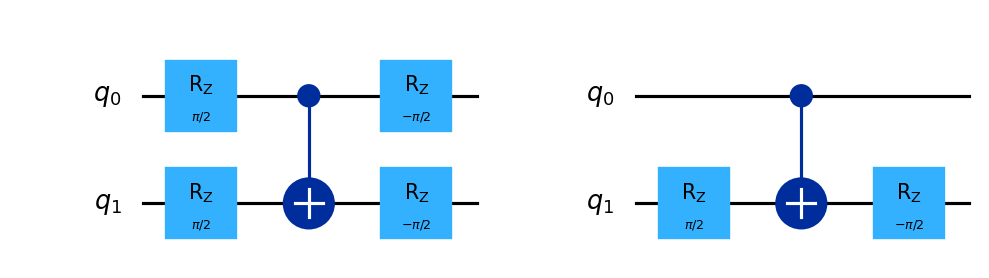

In [52]:
from qiskit.transpiler.passes import CommutativeCancellation

circuit = QuantumCircuit(2)

circuit.rz(np.pi/2, 0)
circuit.rz(np.pi/2, 1)
circuit.cx(0, 1)
circuit.rz(-np.pi/2, 0)
circuit.rz(-np.pi/2, 1)


pm_inv = PassManager(CommutativeCancellation())
optimized_circuit = pm_inv.run(circuit)
optimized_circuit.draw('mpl')

fig, ax = plt.subplots(1, 2, figsize=(10, 7))

circuit.draw('mpl', ax=ax[0])
optimized_circuit.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

### A "SABRE" pipeline pass strategically maps your virtual qubits to physical hardware. It works by simulating multiple layout attempts and choosing the one that minimizes the number of SWAP gates required to execute your circuit.

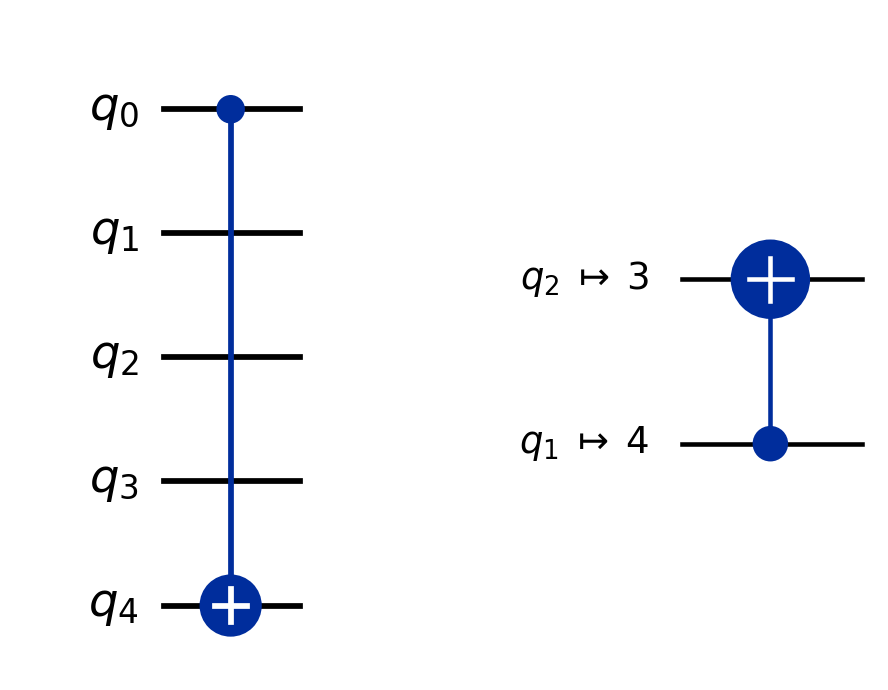

In [517]:
from qiskit.transpiler.passes import SabreLayout, SabreSwap, FullAncillaAllocation, EnlargeWithAncilla, ApplyLayout
from qiskit.providers.fake_provider import GenericBackendV2

# 1. Setup Environment
backend = GenericBackendV2(num_qubits=5)
coupling_map = backend.coupling_map
circuit = QuantumCircuit(5)
circuit.cx(0, 4)

# 2. Define the Sabre Pass Manager
# SabreLayout finds the best initial mapping by running internal routing trials
sabre_pass = SabreLayout(coupling_map=coupling_map, layout_trials=10)

# 3. Create a Pass Manager to apply the discovered layout
# We must include ancillary allocation and ApplyLayout to transform the circuit
pm = PassManager([
    sabre_pass,
    FullAncillaAllocation(coupling_map),
    EnlargeWithAncilla(),
    ApplyLayout(),
    SabreSwap(coupling_map)
])

# 4. Run the Pass Manager
translated_circuit = pm.run(circuit)

# -----------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 7))

circuit.draw('mpl', ax=ax[0])
translated_circuit.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

### The last pass we will look at is the `BasisTranslator`. This allows us to specify which gates are native to our hardware and will automatically (try) to translate input gates to this gate set.

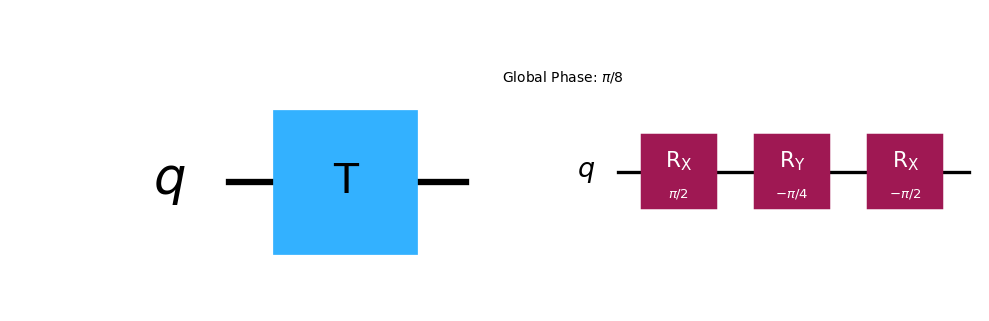

In [491]:
from qiskit.transpiler.passes import BasisTranslator
from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary as sel

# A simple T gate
circuit = QuantumCircuit(1)
circuit.t(0)

# We tell the manager the hardware only knows ['rx', 'ry']
pm = PassManager(BasisTranslator(sel, target_basis=['rx', 'ry']))
translated_circuit = pm.run(circuit)

fig, ax = plt.subplots(1, 2, figsize=(10, 7))

circuit.draw('mpl', ax=ax[0])
translated_circuit.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

### We can specify many different passes for our hardware and append them to a custom `PassManager`. When we `run` a circuit through our `PassManager` it will run in the order in which we appended. We can track how long each pass takes with a simple logging function.

Pass: CommutativeCancellation completed in 0.00032282s
Pass: InverseCancellation completed in 0.00004315s
Pass: Optimize1qGatesDecomposition completed in 0.00005293s
Pass: BasisTranslator completed in 0.00085402s


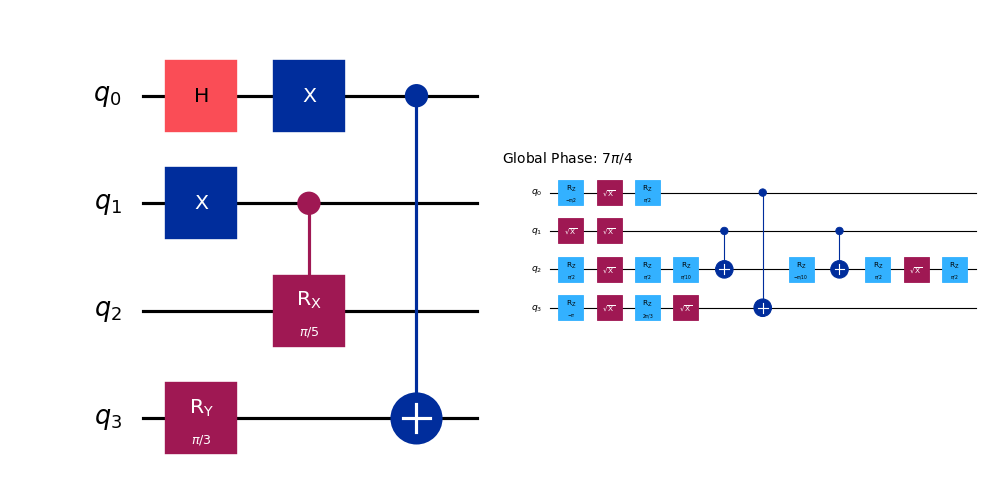

In [499]:
from qiskit.transpiler.passes import (
    CommutativeCancellation, 
    InverseCancellation, 
    BasisTranslator,
    Optimize1qGatesDecomposition
)

circ = QuantumCircuit(4)
circ.h(0)
circ.x([0,1])
circ.ry(np.pi/3, 3)
circ.cx(0,3)
circ.crx(np.pi/5,1,2)

# 1. Define the Hardware's "Language" (Basis Gates)
# Let's pretend our hardware only understands: Rz, SX (Square-root X), and CX
hardware_basis = ['rz', 'sx', 'cx']

# 2. Construct the Pipeline
# Order: Global Clean -> Local Clean -> Simplify 1Q -> Translate to Hardware
custom_pm = PassManager([
    CommutativeCancellation(),                          # The 'X-Ray' cleaner
    InverseCancellation(),                              # The 'Pattern' matcher
    Optimize1qGatesDecomposition(basis=hardware_basis), # Combine Rx + Ry into one
    BasisTranslator(sel, target_basis=hardware_basis)   # Final translation
])

# A simple way to "watch" the passes work
def log_passes(pass_, dag, time, property_set, count):
    print(f"Pass: {pass_.name()} completed in {time:.8f}s")

# 3. Run it on the circuit
optimized_circ = custom_pm.run(circ, callback=log_passes)

# ---------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 7))
circ.draw('mpl', ax=ax[0])
optimized_circ.draw('mpl', ax=ax[1])

plt.tight_layout()
plt.show()

In [492]:
import qiskit.transpiler.passes as qp

all_passes = [name for name in dir(qp) if name[0].isupper() and 'Pass' not in name]

print(f"List of all Passes in Qiskit Library")
print("-" * 100)

for i in range(0, len(all_passes), 3):
    cols = all_passes[i:i+3]
    print("".join(word.ljust(40) for word in cols))

List of all Passes in Qiskit Library
----------------------------------------------------------------------------------------------------
ALAPScheduleAnalysis                    AQCSynthesisPlugin                      ASAPScheduleAnalysis                    
ApplyLayout                             BarrierBeforeFinalMeasurements          BasicSwap                               
BasisTranslator                         CSPLayout                               CheckGateDirection                      
CheckMap                                CliffordUnitarySynthesis                Collect1qRuns                           
Collect2qBlocks                         CollectAndCollapse                      CollectCliffords                        
CollectLinearFunctions                  CollectMultiQBlocks                     CommutationAnalysis                     
CommutativeCancellation                 CommutativeInverseCancellation          CommutativeOptimization                 
Commuting2qGate